<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [9]:
print("Loading STL-10 Dataset...")

(ds_train, ds_test), ds_info = tfds.load(
    'stl10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

class_names = ['Airplane', 'Bird', 'Car',   'Cat',  'Deer',
               'Dog',      'Horse','Monkey', 'Ship', 'Truck']

print(f"Train size : {ds_info.splits['train'].num_examples}")
print(f"Test size  : {ds_info.splits['test'].num_examples}")
print(f"Classes    : {class_names}")

Loading STL-10 Dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.JIIAC5_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.JIIAC5_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.
Train size : 5000
Test size  : 8000
Classes    : ['Airplane', 'Bird', 'Car', 'Cat', 'Deer', 'Dog', 'Horse', 'Monkey', 'Ship', 'Truck']


In [10]:
IMG_SIZE   = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

train_ds = (ds_train
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(500)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds  = (ds_test
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

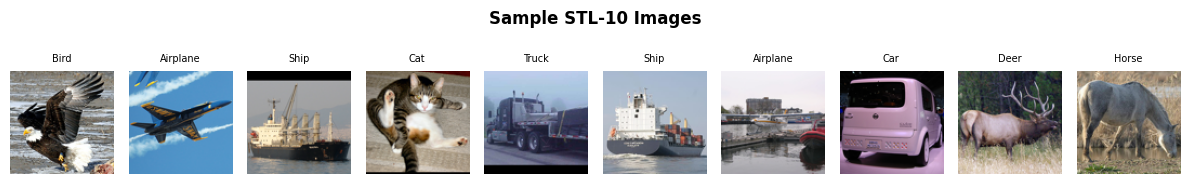

In [11]:
sample_images, sample_labels = next(iter(
    ds_train.batch(10).take(1)
))

plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(sample_images[i].numpy())
    plt.title(class_names[sample_labels[i]], fontsize=7)
    plt.axis('off')
plt.suptitle('Sample STL-10 Images', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print("\nLoading ResNet50 (ImageNet weights)...")

base_model = tf.keras.applications.ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

print(f"Total Layers : {len(base_model.layers)}")
print(f"Total Params : {base_model.count_params():,}")


Loading ResNet50 (ImageNet weights)...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total Layers : 175
Total Params : 23,587,712


In [13]:
base_model.trainable = False
print(f"\nPhase 1 - Base Model : FROZEN")

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10,  activation='softmax')  # 10 STL classes
], name='ResNet50_STL10')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Phase 1 - Base Model : FROZEN


Model: "ResNet50_STL10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
print("\nPhase 1: Training Head Only...")
history_frozen = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    verbose=1
)

loss_frozen, acc_frozen = model.evaluate(test_ds, verbose=0)
print(f"\nPhase 1 → Accuracy: {acc_frozen*100:.2f}% | Loss: {loss_frozen:.4f}")


Phase 1: Training Head Only...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 136ms/step - accuracy: 0.8158 - loss: 0.6990 - val_accuracy: 0.8857 - val_loss: 0.3415
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.8990 - loss: 0.3016 - val_accuracy: 0.8894 - val_loss: 0.3570
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9298 - loss: 0.2059 - val_accuracy: 0.8953 - val_loss: 0.3589
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.9442 - loss: 0.1679 - val_accuracy: 0.8956 - val_loss: 0.3647
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.9524 - loss: 0.1261 - val_accuracy: 0.8955 - val_loss: 0.3777
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9694 - loss: 0.0924 - val_accuracy: 0.8971 - val_loss: 0.3868
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.9748 - loss: 0.0750 - val_accuracy: 0.8992 - val_loss: 0.3937
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - a

In [15]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"\nPhase 2 - Last 20 Layers : UNFROZEN")
print(f"Trainable Layers         : {trainable}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Phase 2 - Last 20 Layers : UNFROZEN
Trainable Layers         : 20


In [16]:
print("\nPhase 2: Fine-tuning Last 20 Layers...")
history_finetune = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    verbose=1
)

loss_finetune, acc_finetune = model.evaluate(test_ds, verbose=0)
print(f"\nPhase 2 → Accuracy: {acc_finetune*100:.2f}% | Loss: {loss_finetune:.4f}")


Phase 2: Fine-tuning Last 20 Layers...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 149ms/step - accuracy: 0.9688 - loss: 0.0943 - val_accuracy: 0.8965 - val_loss: 0.4241
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.9892 - loss: 0.0383 - val_accuracy: 0.8989 - val_loss: 0.3826
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.9942 - loss: 0.0200 - val_accuracy: 0.9003 - val_loss: 0.4052
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.9962 - loss: 0.0137 - val_accuracy: 0.9029 - val_loss: 0.4140
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.9962 - loss: 0.0131 - val_accuracy: 0.9081 - val_loss: 0.3813
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.9952 - loss: 0.0139 - val_accuracy: 0.9049 - val_loss: 0.4353
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.9968 - loss: 0.0094 - val_accuracy: 0.9066 - val_loss: 0.4217
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/

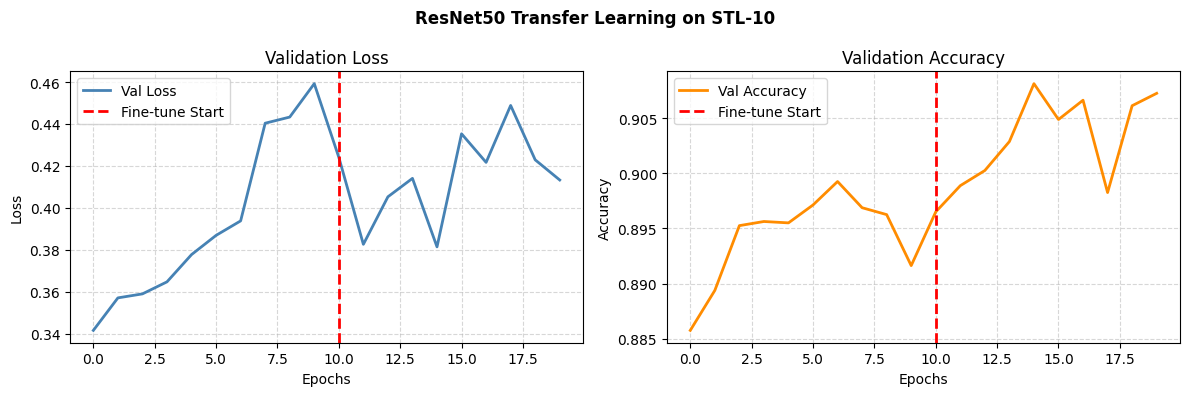

In [20]:
all_val_loss = (history_frozen.history['val_loss'] +
                history_finetune.history['val_loss'])
all_val_acc  = (history_frozen.history['val_accuracy'] +
                history_finetune.history['val_accuracy'])

phase1_end = len(history_frozen.history['val_loss'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(all_val_loss, color='steelblue', linewidth=2, label='Val Loss')
axes[0].axvline(x=phase1_end, color='red',
                linestyle='--', linewidth=2, label='Fine-tune Start')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Accuracy
axes[1].plot(all_val_acc, color='darkorange', linewidth=2, label='Val Accuracy')
axes[1].axvline(x=phase1_end, color='red',
                linestyle='--', linewidth=2, label='Fine-tune Start')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('ResNet50 Transfer Learning on STL-10', fontweight='bold')
plt.tight_layout()
plt.show()